In [9]:
import pandas as pd

df = pd.read_csv("Titanic-Dataset.csv")

df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'Titanic-Dataset.csv'

In [11]:
import os

print(os.getcwd())

d:\Titanic_Survival_Prediction\Titanic_Survival_Prediction.ipynb


In [12]:
os.listdir()

['Titanic-Dataset.csv.csv', 'Titanic_Survival_Prediction.ipynb']

In [13]:
import pandas as pd

df = pd.read_csv("Titanic-Dataset.csv.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [14]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [15]:
df.shape

(418, 12)

In [16]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [17]:
df["Title"] = df["Name"].str.extract(' ([A-Za-z]+)\.', expand=False)

df[["Name","Title"]].head()

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
C:\Users\HP\AppData\Local\Temp\ipykernel_18340\3529326803.py:1: SyntaxWarning: invalid escape sequence '\.'
  df["Title"] = df["Name"].str.extract(' ([A-Za-z]+)\.', expand=False)


,Name,Title
0,"Kelly, Mr. James",Mr
1,"Wilkes, Mrs. James (Ellen Needs)",Mrs
2,"Myles, Mr. Thomas Francis",Mr
3,"Wirz, Mr. Albert",Mr
4,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",Mrs


In [18]:
df["Title"].value_counts()

Title
Mr        240
Miss       78
Mrs        72
Master     21
Col         2
Rev         2
Ms          1
Dr          1
Dona        1
Name: count, dtype: int64

In [19]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

df[["SibSp","Parch","FamilySize"]].head()

,SibSp,Parch,FamilySize
0,0,0,1
1,1,0,2
2,0,0,1
3,0,0,1
4,1,1,3


In [20]:
df["CabinPresent"] = df["Cabin"].notnull().astype(int)

df["CabinPresent"].value_counts()

CabinPresent
0    327
1     91
Name: count, dtype: int64

In [21]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [22]:
df["Age"].isnull().sum()

np.int64(0)

In [23]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [24]:
df["Embarked"].isnull().sum()

np.int64(0)

In [25]:
df.drop(
    ["PassengerId", "Name", "Ticket", "Cabin"],
    axis=1,
    inplace=True
)

In [26]:
df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked', 'Title', 'FamilySize', 'CabinPresent'],
      dtype='str')

In [27]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in ["Sex", "Embarked", "Title"]:
    df[col] = le.fit_transform(df[col])

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,FamilySize,CabinPresent
0,0,3,1,34.5,0,0,7.8292,1,5,1,0
1,1,3,0,47.0,1,0,7.0000,2,6,2,0
2,0,2,1,62.0,0,0,9.6875,1,5,1,0
3,0,3,1,27.0,0,0,8.6625,2,5,1,0
4,1,3,0,22.0,1,1,12.2875,2,6,3,0


In [28]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

print(X.shape)
print(y.shape)

(418, 10)
(418,)


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(334, 10)
(84, 10)


In [30]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [31]:
y_pred = rf.predict(X_test)

print(y_pred[:10])

[0 1 0 0 1 0 1 0 1 0]


In [32]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [33]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        34

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



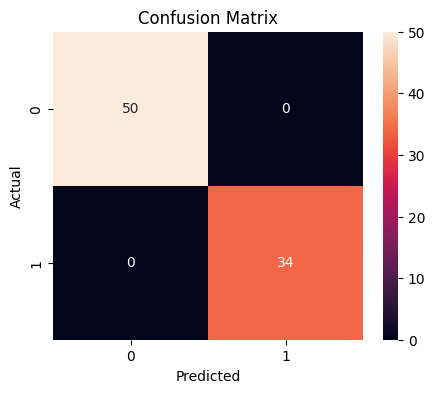

In [34]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [35]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

        Feature  Importance
1           Sex    0.642232
7         Title    0.265434
5          Fare    0.030462
2           Age    0.023188
8    FamilySize    0.015092
4         Parch    0.006882
6      Embarked    0.005293
3         SibSp    0.004886
0        Pclass    0.003814
9  CabinPresent    0.002715


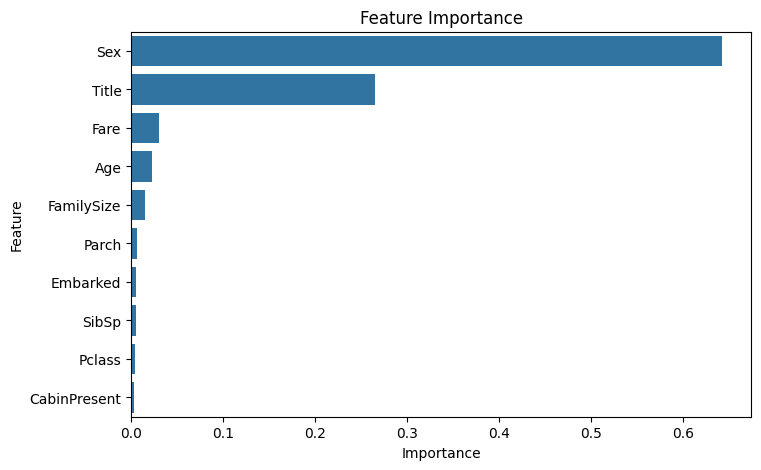

In [36]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")
plt.show()

In [37]:
import joblib

joblib.dump(rf, "titanic_model.pkl")

print("Model Saved")

Model Saved


In [38]:
sample = X.iloc[[0]]

prediction = rf.predict(sample)

print("Prediction:", prediction[0])

Prediction: 0


In [39]:
!pip install shap

   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/38.1 MB ? eta -:--:--
    --------------------------------------- 0.5/38.1 MB 855.4 kB/s eta 0:00:44
    --------------------------------------- 0.5/38.1 MB 855.4 kB/s eta 0:00:44
    --------------------------------------- 0.8/38.1 MB 822.3 kB/s eta 0:00:46
   - -------------------------------------- 1.0/38.1 MB 823.5 kB/s eta 0:00:46
   - -------------------------------------- 1.0/38.1 MB 823.5 kB/s eta 0:00:46
   - -------------------------------------- 1.0/38.1 MB 823.5 kB/s eta 0:00:46
   - -------------------------------------- 1.3/38.1 MB 714.2 kB/s eta 0:00:52
   - -------------------------------------- 1.3/38.1 MB 714.2 kB/s eta 0:00:52
   - -------------


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [40]:
import shap

explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_test)

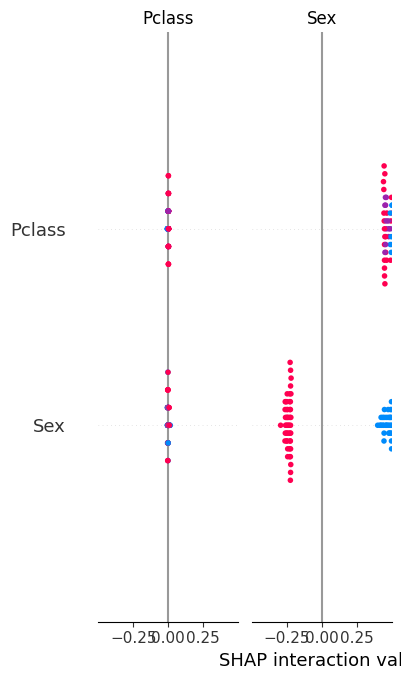

In [41]:
shap.summary_plot(shap_values, X_test)